In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Final_Crime_Dataset.csv')
df = df.drop_duplicates(subset=['IncidntNum', 'Category'])

#Drop rows that dont have a police district
df = df.dropna(subset=['PdDistrict'])
df = df[df['PdDistrict'] != 'OUT OF SF']
#print(df.columns)

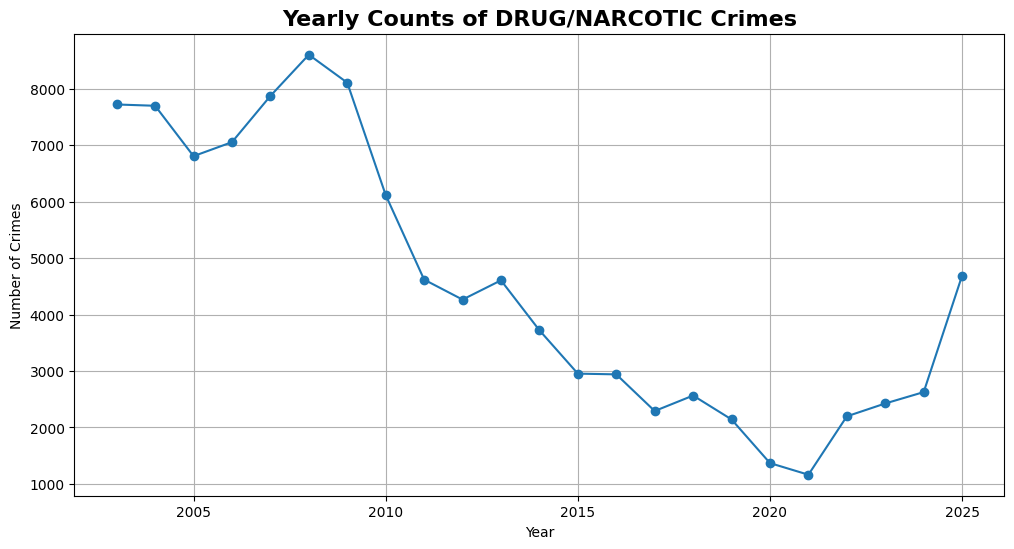

In [ ]:
df['Year'] = pd.to_datetime(df['Date'], format='%Y-%m-%d').dt.year
df = df[df['Year'] <= 2025]
Category = df['Category'].unique()

drug_df = df[df['Category'] == 'DRUG/NARCOTIC']
plt.figure(figsize=(12, 6))
yearly_counts = drug_df.groupby('Year').size()
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title('Yearly Counts of DRUG/NARCOTIC Crimes', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.grid()
plt.show()

plt.savefig('drug_narcotic_crimes.png')




-Looking into drug crime data because one of the most talked about issues in California/San Fran Polictics
<br>-Exploration of how diffrent policies have affected this issues and the data regarding this topic
<br>-Big drop from 2009 to 2011, could be explained by Obama's Fair Sentencing Act(2010) (https://www.congress.gov/bill/111th-congress/senate-bill/1789).
<br>-Increased the mininum weight of certain drugs for it to be a felony or a crime.
<br>-Rise after 2021, could be attributed to Governer Newsom's policy to crack down on fentanyl(https://www.gov.ca.gov/2026/03/31/governor-newsoms-border-strategy-intercepts-54-million-lethal-fentanyl-pills-since-2021/) 
<br>-This included a 30 mil state budget and a no nonsense approch to posession of fentanyl.
<br>-Another spike in 2025, could have been cuased by Mayor of SF Daniel Lurie's decison to stop distribution of supplies and apprarutus related with fentanyal without counselling and treatment which could have resulted to people turning to illegal dealers and uptick in drug related crime.(https://www.sf.gov/news-mayor-lurie-ends-distribution-of-fentanyl-smoking-supplies-without-counseling-and-treatment)

In [ ]:
from folium.plugins import HeatMapWithTime
import folium as fl

# 1. Filter and clean data
drug_df = df[df['Category'] == 'DRUG/NARCOTIC'].copy()
drug_df['Date'] = pd.to_datetime(drug_df['Date'])
drug_df['Year'] = drug_df['Date'].dt.year

# 2. Extract coordinates (handling the "POINT (long lat)" string format)
# Note: Usually 'location' is 'POINT (long lat)', so long is index 0, lat is index 1
coords = (
    drug_df['location']
    .str.replace('POINT \(', '', regex=True)
    .str.replace('\)', '', regex=True)
    .str.split(' ', expand=True)
)
drug_df['longitude'] = coords[0].astype(float)
drug_df['latitude'] = coords[1].astype(float)
drug_df = drug_df.dropna(subset=['latitude', 'longitude'])

# 3. Prepare data for HeatMapWithTime
# We need a list of lists: [[lat, lon], [lat, lon]] for each time step
heat_time_data = []
time_index = sorted(drug_df['Year'].unique()) # Get actual years from data

for year in time_index:
    # Filter for the year and create a list of [lat, lon] pairs
    year_data = drug_df[drug_df['Year'] == year][['latitude', 'longitude']].values.tolist()
    heat_time_data.append(year_data)

# 4. Create the Map
# Using 'folium' instead of 'fl' unless you aliased it specifically
H_map_SF = fl.Map(location=[37.7749, -122.4194], zoom_start=12)

# 5. Add HeatMapWithTime
# Added 'index' parameter so the labels show the actual years
hm = HeatMapWithTime(
    heat_time_data, 
    index=[str(y) for y in time_index], 
    auto_play=True, 
    max_opacity=0.8
)
hm.add_to(H_map_SF)

# 6. Display the map
H_map_SF.save('drug_narcotic_heatmap.html')
H_map_SF


<br>-We also want to explore how this has changed landscape of drug related crime in SF.
<br>-Went from more spread to concentrated in a particular part on the city, 
<br>-Comparing 2003 and 2025,
<br>-In 2003 Tenderloin (0.27), Southern (0.21), Missions(0.21) had combined 69% of SF's drug related crime
<br>-In 2025 they had a combined 83% with Tenderloin (0.37), Southern (0.23) and Missions (0.23). Tenderloin expericing uptick in the number of drug relataed crimes.
<br>-Cruroius if this is unique to just drugs so we looked in the relative crime rates for some of the crimes with high number of incidents and compared it with drugs

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

df['PdDistrict'] = df['PdDistrict'].str.upper()
df['Category'] = df['Category'].str.upper()
GROUP_A_LIST = ['TENDERLOIN', 'SOUTHERN', 'MISSION']

df_cat = df.groupby(['Category', 'Year', 'PdDistrict']).size().reset_index(name='count')
df_cat['relative_rate'] = df_cat['count'] / df_cat.groupby(['Category', 'Year'])['count'].transform('sum')

df_total = df.groupby(['Year', 'PdDistrict']).size().reset_index(name='count')
df_total['relative_rate'] = df_total['count'] / df_total.groupby('Year')['count'].transform('sum')
df_total['Category'] = 'OVERALL CITY TREND'

df_combined = pd.concat([df_cat, df_total], ignore_index=True)
all_options = sorted(df_combined['Category'].unique())

all_districts = sorted(df_cat['PdDistrict'].unique())
other_districts = [d for d in all_districts if d not in GROUP_A_LIST]
sorted_districts = GROUP_A_LIST + other_districts 

colors_core = px.colors.sequential.Reds[4:9]
colors_other = px.colors.sequential.Blues[2:9]
color_map = {dist: colors_core[i % len(colors_core)] for i, dist in enumerate(GROUP_A_LIST)}
for i, dist in enumerate(other_districts):
    color_map[dist] = colors_other[-(i % len(colors_other) + 1)]

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Percentage of Cases by chosen Category", "Percentage of Drug cases 2003-2025 per district"),
    horizontal_spacing=0.1
)

for opt in all_options:
    temp_df = df_combined[df_combined['Category'] == opt]
    for dist in sorted_districts:
        dist_data = temp_df[temp_df['PdDistrict'] == dist].sort_values('Year')
        fig.add_trace(
            go.Scatter(
                x=dist_data['Year'], y=dist_data['relative_rate'],
                name=dist, stackgroup='one', groupnorm='fraction',
                legendgroup=dist, fillcolor=color_map[dist],
                line=dict(width=0.5, color='rgba(255,255,255,0.3)'),
                visible=(opt == all_options[0]) 
            ), row=1, col=1
        )

drug_category = 'DRUG/NARCOTIC' 
df_drugs = df_cat[df_cat['Category'] == drug_category]

for dist in sorted_districts:
    dist_drug_data = df_drugs[df_drugs['PdDistrict'] == dist].sort_values('Year')
    fig.add_trace(
        go.Scatter(
            x=dist_drug_data['Year'], y=dist_drug_data['relative_rate'],
            stackgroup='two', groupnorm='fraction',
            name=dist, legendgroup=dist, showlegend=False,
            fillcolor=color_map[dist],
            line=dict(width=0.5, color='rgba(255,255,255,0.3)'),
            visible=True 
        ), row=1, col=2
    )

buttons = []
num_districts = len(sorted_districts)
static_start_idx = len(all_options) * num_districts 

for i, opt in enumerate(all_options):
    visibility = [False] * static_start_idx
    for j in range(i * num_districts, (i + 1) * num_districts):
        visibility[j] = True
    visibility.extend([True] * num_districts) # Always show the Drug plot
        
    buttons.append(dict(
        label=opt, method="update",
        args=[{"visible": visibility}, {"title": f"Comparison: {opt} vs DRUG/NARCOTIC"}]
    ))

fig.update_layout(
    updatemenus=[{"buttons": buttons, "x": 1.15, "y": 1.3, "xanchor": "right", "yanchor": "top"}],
    yaxis=dict(range=[0, 1], tickformat='.0%'),
    yaxis2=dict(range=[0, 1], tickformat='.0%'),
    legend=dict(
        itemclick=False,     
        itemdoubleclick=False, 
        traceorder="normal"
    ),
    margin=dict(t=120),
    hovermode="x unified",
    template="plotly_white"
)

fig.show()
fig.write_html('category_district_comparison.html')

<br>When comparing against other trends the they havent gotten as concentrated around in one area, but have stuck around in simialar areas.
<br>Taking Larceny/Theft for example the top 4 at 2003 Southern, Mission, Central and Northen had a combined, 63% and in 2025 still have the majority of this crime type containig 61% of the crime, similar rates. An in depth look int every crime type would also be interesting.   
<br>Another intresting thing to note is that we have a increase crime data on Tenderloin, Southern and Missions since 2023. Would be intresting to see what has cuased this?
<br> Is there more policing in these area now? Are there any other major policy changes that could be related to this uptick? Could also be something to look into?    